In [51]:
import os
import librosa 
import librosa.display
import numpy as np 
import matplotlib.pyplot as plt 

%matplotlib inline

In [52]:
DATA_DIR = r"D:\codeAlpha_tasks\Task3\data\archive\audio_speech_actors_01-24"

actors = sorted(os.listdir(DATA_DIR))

print(f"Number of actor Folders: {len(actors)}")
print(actors[:5])

Number of actor Folders: 24
['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05']


In [53]:
sample_actor= os.path.join(DATA_DIR,"Actor_01")
sample_files = os.listdir(sample_actor)
print(f"files in Actor_01: {len(sample_files)}")
print(sample_files[:3])

sample_path = os.path.join(sample_actor,sample_files[0])
y,sr = librosa.load(sample_path,sr = None)
print(f"Sample rate : {sr}, Duration:{len(y)/sr:.2f}sec, Shape: {y.shape}")

files in Actor_01: 60
['03-01-01-01-01-01-01.wav', '03-01-01-01-01-02-01.wav', '03-01-01-01-02-01-01.wav']
Sample rate : 48000, Duration:3.30sec, Shape: (158558,)


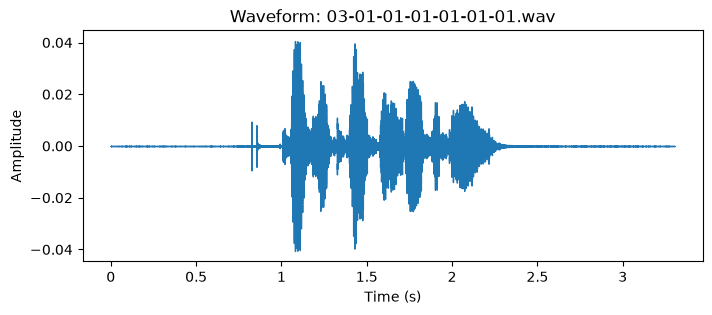

In [54]:
plt.figure(figsize=(8,3))
librosa.display.waveshow(y,sr=sr)
plt.title(f"Waveform: {sample_files[0]}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


MFCC shape: (13, 310)


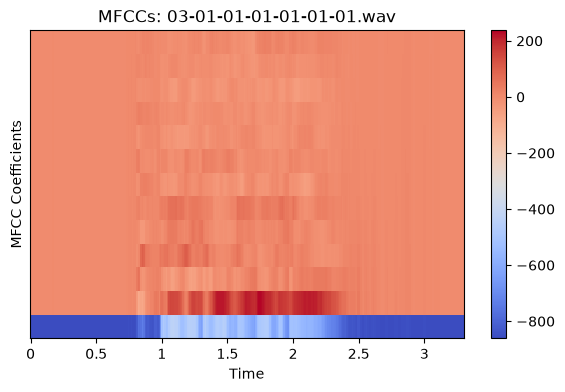

In [55]:
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print(f"MFCC shape: {mfccs.shape}")

plt.figure(figsize=(7, 4))
librosa.display.specshow( mfccs,x_axis='time', sr=sr)
plt.colorbar()
plt.title(f"MFCCs: { sample_files[0]}")
plt.ylabel("MFCC Coefficients")
plt.show()

In [56]:
MAX_LEN = 380
N_MFCC = 13

def extract_features(file_path,max_len = MAX_LEN , n_mfcc = N_MFCC):
    y,sr = librosa.load(file_path,sr = None)
    mfccs = librosa.feature.mfcc(y=y, sr= sr,n_mfcc= n_mfcc)
    
    if mfccs.shape[1] <max_len:
        pad_width =max_len - mfccs.shape[1]
        mfccs = np.pad(mfccs,pad_width=((0,0),(0,pad_width)),mode='constant')    
    else:
        mfccs = mfccs[:, :max_len]
        
    return mfccs

In [57]:
sample_lengths = []
for actor in actors[:3]:
    actor_path = os.path.join(DATA_DIR, actor)
    for file in os.listdir(actor_path):
        y,sr = librosa.load(os.path.join(actor_path,file),sr = None )
        mfccs =librosa.feature.mfcc(y=y,sr = sr , n_mfcc=13)
        sample_lengths.append(mfccs.shape[1])
        
print(f"Min: {min(sample_lengths)}, Max: {max(sample_lengths)}, Avg: {np.mean(sample_lengths):.1f}")

Min: 298, Max: 470, Avg: 353.4


In [58]:
# RAVDESS emotion code mapping
emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

X = []
y_labels = []

for actor in actors:
    actor_path = os.path.join(DATA_DIR, actor)
    for file in os.listdir(actor_path):
        file_path = os.path.join(actor_path, file)
        
        emotion_code = file.split('-')[2]
        emotion = emotion_map[emotion_code]
        
        features = extract_features(file_path)
        
        X.append(features)
        y_labels.append(emotion)

X = np.array(X)
y_labels = np.array(y_labels)

print(f"X shape: {X.shape}")
print(f"y_labels shape: {y_labels.shape}")

X shape: (1440, 13, 380)
y_labels shape: (1440,)


In [60]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

print(f"Classes : {le.classes_}")
print(f"Encoded example: {y_labels[0]} -> {y_encoded[0]}")

y_categorical = to_categorical(y_encoded)
print(f"y_categorical shape: {y_categorical.shape}")

Classes : ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Encoded example: neutral -> 5
y_categorical shape: (1440, 8)
